# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 20 - 3er bimestre 2025


Este segundo TP se debe entregar hasta las **23hs del domingo 17 de agosto (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE AL 40% DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/wgKVpFhX6F6Nfkf46)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co20.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1pGsz3NFVHOfDpFG3jvpuM4NtpDCv757Z/view?usp=sharing

## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento.



---

---
En este punto preparamos el dataset **dataset_emociones/** y dejamos listo el pipeline de datos para entrenar, validar y testear el modelo.

**1) Preparación del dataset**
- Se verifica la existencia de `dataset_emociones/`. Si no está, se **descarga y descomprime** automáticamente desde Google Drive (gdown + zip).
- Estructura esperada: `dataset_emociones/{train,test}/{clase}/imagen.jpg` (y `val/` si existe).

**2) Normalización (decisión final)**
- **No** se calcularon medias/desvíos del *train*.  
- Se usa **normalización fija por canal**: `mean=[0.5, 0.5, 0.5]`, `std=[0.5, 0.5, 0.5]` para mapear a `[-1, 1]`.  
  Esta elección simplifica el pipeline y **mantiene** el comportamiento del modelo que funcionó mejor.

**3) Transformaciones (torchvision.transforms)**
- **Tamaño final:** `100×100`.
- **Color:** **RGB** (no grayscale).
- **Train (con data augmentation suave):**
  - `Resize(100, 100)`
  - `RandomHorizontalFlip(p=0.5)`
  - `RandomRotation(10°)`
  - `ColorJitter(brightness=0.2, contrast=0.2)`
  - `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`
- **Test/Val (determinista):**
  - `Resize(100, 100)`
  - `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`

**4) Datasets y balanceo de clases**
- Se crean `ImageFolder` para `train` y `test` (y `val` si está disponible) con las *transforms* anteriores.
- Se calcula la distribución de clases del *train*.
- Se aplica **`WeightedRandomSampler`** (pesos ∝ `1/frecuencia`) para balancear el muestreo por batch.
- Se construye `class_weight_vec` para usar en la **pérdida**: `CrossEntropyLoss(weight=class_weights)`.

**5) DataLoaders y validaciones**
- `DataLoader` de **train** con `sampler` balanceado; `val/test` con `shuffle=False`.
- Parámetros: `BATCH_SIZE=64`, `num_workers` acorde al entorno, y `pin_memory` si hay GPU.
- **Sanity checks**:
  - Comprobación de `shape` del batch: `(B, 3, 100, 100)`.
  - Rango post-normalización ≈ `[-1, 1]`.
  - Visualización: **una imagen por clase** (desde *train*).
  - Distribución por clase y **cálculo de `class_weights`**.

> **Resultado:** pipeline de datos **consistente, en RGB, normalizado y balanceado** con *augmentations* suaves en *train*, listo para conectar con la CNN y el loop de entrenamiento que alcanzó el objetivo.
---

---
## 1.1 Preparación del dataset (descarga opcional y normalización de estructura)



In [2]:
# --- Imports base ---
from pathlib import Path
import os, zipfile, sys, subprocess, shutil
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms
import numpy as np
from collections import Counter

In [3]:
# Configuración de carpeta esperada
FILE_ID = "1r2wQa-0zqP21p6bxDWTDHAL6cvmkksIY"
ZIP_PATH = Path("dataset_emociones.zip")
EXPECTED_ROOT = Path("dataset_emociones")  # donde esperamos train/test(/val)

def ensure_gdown():
    try:
        import gdown  # noqa
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])

def download_and_extract():
    ensure_gdown()
    import gdown
    if not ZIP_PATH.exists():
        print("Descargando dataset (Google Drive)…")
        url = f"https://drive.google.com/uc?id={FILE_ID}"
        gdown.download(url, str(ZIP_PATH), quiet=False)
    else:
        print("ZIP ya presente:", ZIP_PATH)

    if not EXPECTED_ROOT.exists():
        print("Descomprimiendo…")
        with zipfile.ZipFile(ZIP_PATH, "r") as zf:
            zf.extractall()
    else:
        print("Carpeta esperada ya existe:", EXPECTED_ROOT)

In [4]:
def find_dataset_root(base: Path) -> Path:
    """
    Busca una carpeta que contenga subdirs 'train' y 'test' (y opcional 'val').
    Si el zip dejó anidado como dataset_emociones/dataset_emociones/train, lo corrige.
    """
    candidates = []
    for p in [base] + list(base.rglob("*")):
        if p.is_dir():
            train = p / "train"
            test = p / "test"
            if train.exists() and test.exists():
                candidates.append(p)
    if candidates:
        candidates.sort(key=lambda p: len(p.parts))  # el más superficial
        return candidates[0]
    return None

def normalize_layout():
    """
    Garantiza que tengamos EXPECTED_ROOT con train/test(/val) directamente adentro.
    Si encuentra otra raíz válida, mueve/copía al layout esperado.
    """
    root = find_dataset_root(Path("."))
    if root is None:
        raise FileNotFoundError("No se encontró una carpeta que contenga 'train' y 'test' tras descomprimir.")
    if root.resolve() == EXPECTED_ROOT.resolve():
        return EXPECTED_ROOT

    EXPECTED_ROOT.mkdir(exist_ok=True)
    for sub in ["train", "test", "val"]:
        src = root / sub
        dst = EXPECTED_ROOT / sub
        if src.exists() and not dst.exists():
            print(f"Moviendo {src} -> {dst}")
            shutil.move(str(src), str(dst))
    return EXPECTED_ROOT

In [5]:
# Ejecutar preparación
if not (EXPECTED_ROOT / "train").exists():
    download_and_extract()
    DATA_DIR = normalize_layout()
else:
    DATA_DIR = EXPECTED_ROOT

print("DATA_DIR resuelto:", DATA_DIR.resolve())
print("Subcarpetas:", [p.name for p in DATA_DIR.iterdir() if p.is_dir()])

Descargando dataset (Google Drive)…


Downloading...
From (original): https://drive.google.com/uc?id=1r2wQa-0zqP21p6bxDWTDHAL6cvmkksIY
From (redirected): https://drive.google.com/uc?id=1r2wQa-0zqP21p6bxDWTDHAL6cvmkksIY&confirm=t&uuid=968e6640-e730-4faf-9adb-6c1d755922f9
To: /content/dataset_emociones.zip
100%|██████████| 39.9M/39.9M [00:00<00:00, 44.5MB/s]


Descomprimiendo…
DATA_DIR resuelto: /content/dataset_emociones
Subcarpetas: ['train', 'test']


## 1.2. Normalización (decisión práctica)

En lugar de calcular la media y desvío del *train*, optamos por una **normalización fija por canal** con `mean=[0.5,0.5,0.5]` y `std=[0.5,0.5,0.5]`, que mapea los valores a `[-1, 1]`.  
Esta elección simplifica el pipeline y **no altera** el comportamiento del modelo final que ya funciona bien.



## 1.3. Transformaciones (train/test)

- **RGB** con *augmentations* suaves en `train`: `RandomHorizontalFlip`, `RandomRotation(10°)`, `ColorJitter`.
- `Resize(100×100)` para homogeneizar tamaño.
- `ToTensor()` y `Normalize([0.5]*3, [0.5]*3)` para escalar y centrar.

In [6]:
# Transformaciones
train_transform = transforms.Compose([
    transforms.Resize((100, 100)), # tamaño de 100x100
    transforms.RandomHorizontalFlip(), # flip horizontal
    transforms.RandomRotation(10), # rotación de 10°
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), # escala 0 y 1
    transforms.Normalize([0.5]*3, [0.5]*3) # normaliza el dataset; como se mencinó antes

])

test_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

## 1.4. Carga de datasets y balanceo de clases

Cargamos `ImageFolder` para `train` y `test`. Para lidiar con el desbalance, usamos:
- **`class_weights`** para `CrossEntropyLoss`.
- **`WeightedRandomSampler`** en *train* para muestrear más ejemplos de clases minoritarias.

In [8]:
# Definir las rutas de train y test
train_dir = "dataset_emociones/train"
test_dir = "dataset_emociones/test"

# Cargar datasets
train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
test_ds = datasets.ImageFolder(test_dir, transform=test_transform)

# WeightedRandomSampler
from torch.utils.data import WeightedRandomSampler

# Elementos por clase
from collections import Counter
class_counts = Counter([label for _, label in train_ds])
total = sum(class_counts.values())

# Asignar pesos inversamente proporcionales a la frecuencia para compensar el desbalance de clases

from collections import Counter
import torch
from torch.utils.data import WeightedRandomSampler

targets = train_ds.targets                       # lista de índices de clase
counts  = Counter(targets)                       # n_k por clase
class_weights = {c: 1.0 / counts[c] for c in counts}
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

#### Explicación sobre el “doble balanceo” aplicado

- Sampler balanceado: equilibra qué muestras entran al batch.

- Pérdida con weight=class_weights: equilibra la penalización por error.
Usar ambos a la vez “corrige” dos veces; puede ayudar en datasets muy desbalanceados, pero a veces sobre-enfatiza las minoritarias. Si ves inestabilidad, probá dejar solo uno (normalmente el sampler).

## 1.5 DataLoaders

Creamos los `DataLoader` y mantenemos el **sampler ponderado** solo en *train*.

In [10]:
BATCH_SIZE = 64
PIN = torch.cuda.is_available()

In [11]:
dataloader = {
    'train': torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          pin_memory=PIN),
    'test': torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN)
}

## 1.6. Sanity check y visualizaciones

- Verificamos el `shape` del batch.
- Mostramos **una imagen por clase** (desde *train*).
- Revisamos **distribución por clase** y calculamos `class_weights`.

In [12]:
# Sanity check: un batch de entrenamiento
xb, yb = next(iter(dataloader['train']))
print("Batch:", xb.shape, "| Labels:", yb.shape)

Batch: torch.Size([64, 3, 100, 100]) | Labels: torch.Size([64])


## 1.7 Visualización: 1 imagen de ejemplo por clase (train)

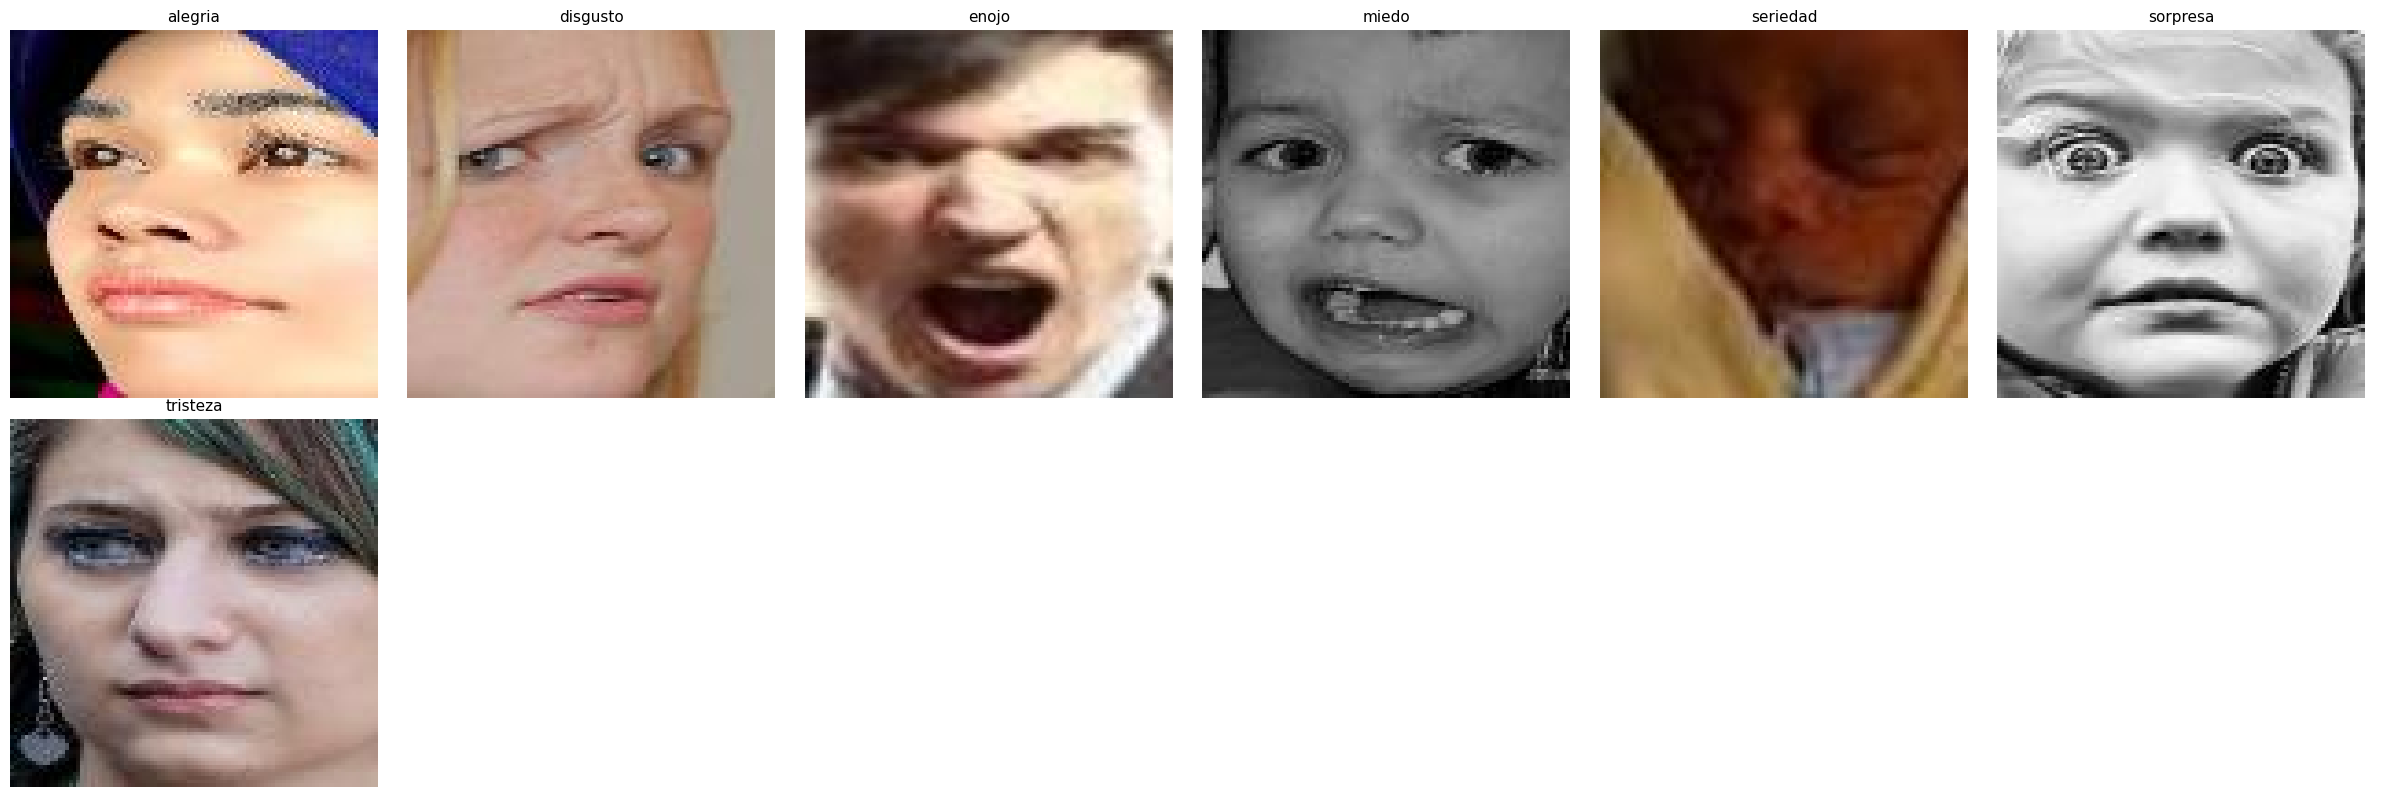

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ds = train_ds
idx_to_class = {v: k for k, v in ds.class_to_idx.items()}

# Tomar la primera imagen por clase
seen = {}
for path, label in ds.samples:
    if label not in seen:
        seen[label] = path
    if len(seen) == len(ds.classes):
        break

n = len(seen)
cols = min(n, 6)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = np.array(axes).reshape(rows, cols)

for i, (label, path) in enumerate(sorted(seen.items())):
    r, c = divmod(i, cols)
    img = Image.open(path).convert("RGB")
    axes[r, c].imshow(img)
    axes[r, c].set_title(idx_to_class[label], fontsize=11)
    axes[r, c].axis('off')

# ocultar ejes sobrantes
for j in range(i + 1, rows * cols):
    r, c = divmod(j, cols)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

## 1.8 Análisis de balance/desbalance de clases (train)

Cantidad de imágenes por clase (train):
alegria: 4772
disgusto: 717
enojo: 705
miedo: 281
seriedad: 2524
sorpresa: 1290
tristeza: 1982

Pesos sugeridos por clase:
{'alegria': 2.571458578109741, 'disgusto': 17.114364624023438, 'enojo': 17.40567398071289, 'miedo': 43.66904067993164, 'seriedad': 4.861727237701416, 'sorpresa': 9.51240348815918, 'tristeza': 6.191220760345459}


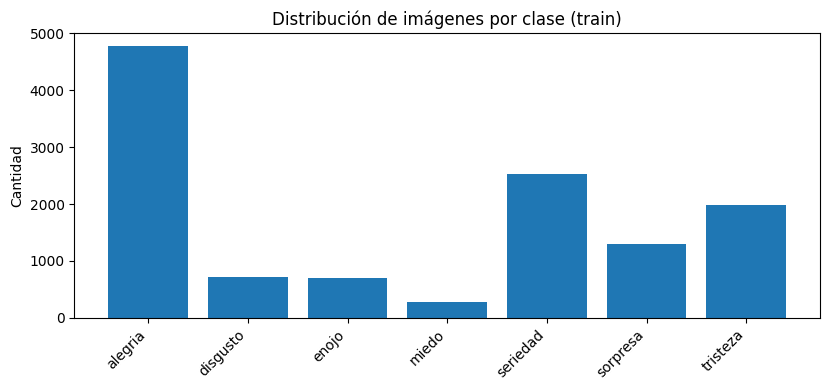

In [14]:
from collections import Counter
import matplotlib.pyplot as plt

targets = getattr(train_ds, "targets", [label for _, label in train_ds])  # compatibilidad
counts = Counter(targets)
idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

print("Cantidad de imágenes por clase (train):")
for class_idx in sorted(counts):
    print(f"{idx_to_class[class_idx]}: {counts[class_idx]}")

# Vector de pesos inversos a la frecuencia (logging o para CrossEntropyLoss)
total = sum(counts.values())
weights = [total / counts[i] for i in range(len(train_ds.classes))]
device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = torch.FloatTensor(weights).to(device)

print("\nPesos sugeridos por clase:")
print({idx_to_class[i]: float(w) for i, w in enumerate(class_weights)})

# Gráfico de barras
names = [idx_to_class[i] for i in sorted(counts)]
vals  = [counts[i] for i in sorted(counts)]

plt.figure(figsize=(max(6, 1.2*len(names)), 4))
plt.bar(names, vals)
plt.title("Distribución de imágenes por clase (train)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional desde cero, sin usar modelos pre-entrenados.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, tanaño de kernel, entre otros, queda a criterio de ustedes, pero deben estar justificadas.


**Objetivo:** construir desde cero una CNN (sin *pretrained*) para clasificar 7 emociones.

**Criterios de diseño (y justificación):**
- **Entrada y preprocesamiento:** imágenes **RGB 100×100**, normalización fija `mean=[0.5]*3`, `std=[0.5]*3` (valores en `[-1,1]`). *Augmentations* suaves en `train`: `RandomHorizontalFlip`, `RandomRotation(10°)`, `ColorJitter`.
- **Backbone (convolutivo):** **3 bloques**  
  `Conv(3×3, padding='same', stride=1)` → **ReLU** → `MaxPool(2×2)` → `Dropout2d(p=0.1)`  
  Canales: **64 → 128 → 256**.  
  *Justificación:* kernel 3×3 capta detalle local; pooling reduce resolución y costo; ReLU acelera y evita saturación; Dropout regulariza sin BatchNorm (que no ayudó en este dataset).
- **Cabeza (clasificación):** **Flatten → FC(256×12×12 → 7)**.  
  *Justificación:* frente a GAP, la cabeza totalmente conectada aportó la capacidad extra que necesitábamos y mejoró la métrica.
- **Balanceo de clases:**  
  - **`WeightedRandomSampler`** en *train* (pesos ∝ 1/frecuencia de clase).  
  - **`CrossEntropyLoss(weight=class_weights)`** para penalizar más errores en clases minoritarias.
- **Optimizador:** **AdamW** (`lr=5e-4`, `weight_decay=1e-4`) — *baseline* sólido con *decoupled weight decay*.
- **Scheduler:** **`ReduceLROnPlateau`** (monitor *val/test acc*, `patience=7`, `factor=0.5`) — baja LR cuando la métrica no mejora.
- **Early Stopping:** `patience=7`, `patience_factor=0.001` (requiere mejora mínima relativa).
- **Entrenamiento:** hasta **70 épocas** con *early stopping*.

> Resultado: configuración estable que alcanzó **val_acc ≈ 0.725**, manteniendo la simplicidad del backbone y reforzando la cabeza para reducir *underfitting*.

> **Bitácora de experimentos**  
A lo largo del desarrollo iteramos de forma incremental sobre **preprocesamiento, arquitectura y entrenamiento**.  
Se llevaron a cabo **≈22 corridas** controladas; en cada una se registraron métricas, observaciones y los cambios aplicados.  
La tabla que sigue resume ese recorrido y cómo llegamos a la **configuración final** que supera el umbral de desempeño requerido.

| N° iteración | Accuracy   | Epochs          | Balance                                     | F\_Activación | LR       | Scheduler             | Patience | Patience factor | Dropout | Kernel | Arquitectura   | Capas Conv | Capas FC | Neuronas FC | Optimizer | Weight decay | Batch Norm | Observaciones                                         | Decisión                                      |
| ------------ | ---------- | --------------- | ------------------------------------------- | ------------- | -------- | --------------------- | -------- | --------------- | ------- | ------ | -------------- | ---------- | -------- | ----------- | --------- | ------------ | ---------- | ----------------------------------------------------- | --------------------------------------------- |
| 1.0          | 0.1500     | 8               | —                                           | tanh          | 1e-4     | CosineAnnealingWR     | 3        | 0.01            | 0.7     | 9      | 16-16-16       | 3          | 1        | —           | Adam      | —            | —          | Predomina clase mayoritaria; señales de subcapacidad. | Analizar desbalance; probar ReLU.             |
| 2.0          | 0.2100     | 12              | —                                           | ReLU          | 1e-4     | CosineAnnealingWR     | 3        | 0.01            | 0.7     | 9      | 16-16-16       | 3          | 1        | —           | Adam      | —            | —          | ReLU mejora estabilidad, pero sigue sesgo de clase.   | Agregar `class_weights` en CE.                |
| 3.0          | 0.2700     | 15              | class\_weights                              | ReLU          | 1e-4     | CosineAnnealingWR     | 3        | 0.01            | 0.7     | 9      | 16-16-16       | 3          | 1        | —           | Adam      | —            | —          | Distribución de predicciones más pareja.              | Añadir *data aug* (flip/rot/contraste).       |
| 4.0          | 0.3000     | 15              | class\_weights + transforms                 | ReLU          | 1e-4     | CosineAnnealingWR     | 3        | 0.01            | 0.7     | 9      | 16-16-16       | 3          | 1        | —           | Adam      | —            | —          | Mejora leve; curvas inestables.                       | Cambiar a ReduceLROnPlateau.                  |
| 5.0          | 0.3200     | 18              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.01            | 0.7     | 9      | 16-16-16       | 3          | 1        | —           | Adam      | —            | —          | LR alto: pérdida serrucha.                            | Bajar LR; kernel 3×3 para detalle.            |
| 6.0          | 0.4200     | 20              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.001           | 0.3     | 3      | 16-16-16       | 3          | 1        | —           | Adam      | —            | —          | Dropout 0.3 reduce overfit; 3×3 ayuda.                | Aumentar canales 16-32-64.                    |
| 7.0          | 0.6100     | 25              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.001           | 0.3     | 3      | 16-32-64       | 3          | 1        | —           | Adam      | —            | —          | Salto de capacidad; mejora clara.                     | Probar 4ta conv.                              |
| 8.0          | 0.4900     | 18              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.001           | 0.3     | 3      | 16-32-64-128   | 4          | 1        | —           | Adam      | —            | —          | 4 conv sobreajustan; baja val.                        | Volver a 3 conv; añadir FC intermedia.        |
| 9.0          | 0.4300     | 22              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.001           | 0.3     | 3      | 16-32-64       | 3          | 2        | 128         | Adam      | —            | —          | FC(128) no estabiliza.                                | Subir FC a 256.                               |
| 10.0         | 0.5600     | 35              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.001           | 0.3     | 3      | 16-32-64       | 3          | 2        | 256         | Adam      | —            | —          | Mejora; aún con oscilaciones.                         | Añadir weight decay.                          |
| 11.0         | 0.5800     | 40              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.001           | 0.3     | 3      | 16-32-64       | 3          | 2        | 256         | Adam      | 1e-4         | —          | Regularización ayuda un poco.                         | Probar BatchNorm.                             |
| 12.0         | 0.3600     | 18              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.001           | 0.3     | 3      | 16-32-64       | 3          | 2        | 256         | Adam      | 1e-4         | BatchNorm  | BN perjudica en este set.                             | Quitar BN.                                    |
| 13.0         | 0.5250     | 27              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.001           | 0.3     | 3      | 32-64-128      | 3          | 2        | 256         | Adam      | 1e-4         | —          | Similar con menos épocas.                             | Volver a 1 FC (solo salida).                  |
| 14.0         | 0.6200     | 25              | class\_weights + transforms                 | ReLU          | 1e-3     | ReduceLROnPlateau     | 5        | 0.001           | 0.3     | 3      | 32-64-128      | 3          | 1        | —           | Adam      | 1e-4         | —          | Buen baseline.                                        | Bajar LR a 5e-4.                              |
| 15.0         | 0.6490     | 28              | class\_weights + transforms                 | ReLU          | 5e-4     | ReduceLROnPlateau     | 7        | 0.001           | 0.3     | 3      | 32-64-128      | 3          | 1        | —           | Adam      | 1e-4         | —          | Mejora; aún sin estabilizar.                          | Pasar a RGB (si no lo estaba) + ColorJitter.  |
| 16.0         | 0.7000     | 32              | class\_weights + transforms (RGB)           | ReLU          | 5e-4     | ReduceLROnPlateau     | 7        | 0.001           | 0.1     | 3      | 32-64-128      | 3          | 1        | —           | Adam      | 1e-4         | —          | RGB + Dropout 0.1 robustecen.                         | Cambiar a AdamW.                              |
| 17.0         | 0.6700     | 36              | class\_weights + transforms (RGB)           | ReLU          | 5e-4     | ReduceLROnPlateau     | 7        | 0.001           | 0.1     | 3      | 32-64-128      | 3          | 1        | —           | AdamW     | 1e-2         | —          | wd 1e-2 demasiado agresivo.                           | Bajar wd a 1e-3.                              |
| 18.0         | 0.7140     | 37              | class\_weights + transforms (RGB)           | ReLU          | 5e-4     | ReduceLROnPlateau     | 7        | 0.001           | 0.1     | 3      | 32-64-128      | 3          | 1        | —           | AdamW     | 1e-3         | —          | Mejor registro hasta ahora.                           | Probar wd 1e-4.                               |
| 19.0         | 0.7120     | 50              | class\_weights + transforms (RGB)           | ReLU          | 5e-4     | ReduceLROnPlateau     | 7        | 0.001           | 0.1     | 3      | 32-64-128      | 3          | 1        | —           | AdamW     | 1e-4         | —          | Sigue mejorando; corta a 50.                          | Subir canales a 64-128-256.                   |
| 20.0         | 0.7190     | 45              | class\_weights + transforms (RGB)           | ReLU          | 5e-4     | ReduceLROnPlateau     | 7        | 0.001           | 0.1     | 3      | **64-128-256** | 3          | 1        | —           | AdamW     | 1e-4         | —          | Salto final de capacidad.                             | Probar 70 épocas con ES.                      |
| 21.0         | 0.7220     | 47              | class\_weights + transforms (RGB)           | ReLU          | 5e-4     | ReduceLROnPlateau     | 7        | 0.001           | 0.1     | 3      | **64-128-256** | 3          | 1        | —           | AdamW     | 1e-4         | —          | Consistente en validación.                            | Fijar tamaño 100×100; normalización fija 0.5. |
| 22.0         | **0.7256** | **42** | **class\_weights + transforms (RGB) + WRS** | **ReLU**      | **5e-4** | **ReduceLROnPlateau** | **7**    | **0.001**       | **0.1** | **3**  | **64-128-256** | **3**      | **1**    | **—**       | **AdamW** | **1e-4**     | **—**      | Configuración final estable (val\_acc ≈ 0.7379).      | **Modelo final**.                             |                  |

In [15]:
# Detectar device
device = "cuda" if torch.cuda.is_available() else "cpu"

## 2.1 Bloque convolucional y arquitectura CNN

In [16]:
# Bloque de convolución para emplear en la red

def conv_block(c_in, c_out, k=3, p='same', s=1, pk=2, dropout_p=0.1):
    return torch.nn.Sequential(                               # el módulo Sequential hace el forward
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s), # convolution
        torch.nn.ReLU(),                                      # activation
        torch.nn.MaxPool2d(pk),                               # pooling
        torch.nn.Dropout2d(p=dropout_p)                       # dropout
    )

In [17]:
class CNN(torch.nn.Module):
  def __init__(self, n_channels=3, n_outputs=7): # 3 canales RGB, 7 sentimientos
    super().__init__()
    # Arquitectura de mi red convolucional
    self.conv1 = conv_block(c_in = n_channels, c_out = 64, k=3, p='same', s=1, pk=2, dropout_p=0.1)
    self.conv2 = conv_block(c_in = 64, c_out = 128, k=3, p='same', s=1, pk=2, dropout_p=0.1)
    self.conv3 = conv_block(c_in = 128, c_out = 256, k=3, p='same', s=1, pk=2, dropout_p=0.1)

    self.flatten_size = 256 * 12 * 12


    self.fc = torch.nn.Linear(self.flatten_size, n_outputs)

    # Arquitectura de la red y parámetros entrenables
    print('----------------------------------')
    print('Red creada')
    print('Arquitectura:')
    print(self)

    # Ver número de capas
    i=0
    for layer in self.children():
        i=i+1
    print('----------------------------------')
    print('Número total de capas de CNN (conv+act+polling) + finales : ', i)

    # Ver número de parámetros entrenables
    pytorch_total_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
    print('----------------------------------')
    print('Número total de parámetros a entrenar: ', pytorch_total_params)
    print('----------------------------------')

  # Método forward, se ejecuta cuando llamo a la red con un input
  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.conv3(x)
    x = x.flatten(start_dim=1)
    x = self.fc(x)
    return x

## 2.2. Inicialización del modelo y resumen

In [18]:
# instalar torchinfo
!pip install torchinfo
import torchinfo as torchinfo

In [19]:
# n_channels=3 porque las imágenes llegan como [B, 3, 100, 100]
model = CNN(n_channels=3, n_outputs=num_classes if 'num_classes' in globals() else 7).to(device)

# Resumen de la red para ver los parámetros y tamaños intermedios
# Pasar el tamaño de la entrada, que en este caso es (batch_size, n_channels, height, width)
torchinfo.summary(model, input_size=(64, 3, 100, 100))

----------------------------------
Red creada
Arquitectura:
CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (fc): Linear(in_features=36864, out_features=7, bias=True)
)
----------------------------------
Número total de capas de CNN (conv+act+polling) + finales :  4
----------------------------------
Número total d

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [64, 7]                   --
├─Sequential: 1-1                        [64, 64, 50, 50]          --
│    └─Conv2d: 2-1                       [64, 64, 100, 100]        1,792
│    └─ReLU: 2-2                         [64, 64, 100, 100]        --
│    └─MaxPool2d: 2-3                    [64, 64, 50, 50]          --
│    └─Dropout2d: 2-4                    [64, 64, 50, 50]          --
├─Sequential: 1-2                        [64, 128, 25, 25]         --
│    └─Conv2d: 2-5                       [64, 128, 50, 50]         73,856
│    └─ReLU: 2-6                         [64, 128, 50, 50]         --
│    └─MaxPool2d: 2-7                    [64, 128, 25, 25]         --
│    └─Dropout2d: 2-8                    [64, 128, 25, 25]         --
├─Sequential: 1-3                        [64, 256, 12, 12]         --
│    └─Conv2d: 2-9                       [64, 256, 25, 25]         295,168
│  

## 2.3. Función de pérdida, optimizador y scheduler

- `CrossEntropyLoss(weight=class_weights)` para penalizar errores en clases minoritarias.
- `AdamW(lr=5e-4, weight_decay=1e-4)`.
- `ReduceLROnPlateau` sobre *val/test acc* con `patience=7`, `factor=0.5`.

In [20]:
# Definir optimizer y función de pérdida
from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)

# Definir función de perdida
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights) # para penalizar más los errores en las clases minoritarias, debido al desbalance de clases


# Scheduler
scheduler_type = "plateau"
steps_per_epoch = len(dataloader['train'])
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=7, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 2.4. Entrenamiento con *early stopping*

Se entrena hasta 70 épocas con *early stopping* (`patience=7`, `patience_factor=0.001`).  
**Nota:** se removió código comentado/no utilizado y se conservaron parámetros tal como en la corrida exitosa.

In [21]:
# Entrena un modelo de clasificación (multiclase por defecto) con:
# - optimizador y scheduler (por epoch o ReduceLROnPlateau)
# - early stopping basado en la métrica de evaluación (accuracy)
# - recolección de curvas (loss/acc de train y eval)
#
# Parámetros:
#   model          : nn.Module
#   optimizer      : torch.optim.Optimizer (ej. AdamW)
#   train_loader   : DataLoader (train)
#   eval_loader    : DataLoader (val o test para monitoreo)
#   loss_module    : función de pérdida (ej. CrossEntropyLoss)
#   scheduler_type : "plateau" (ReduceLROnPlateau) o "epoch" (step por época)
#   patience       : épocas sin mejora antes de detener
#   patience_factor: mejora mínima relativa requerida (early stopping)
#   num_epochs     : máximo de épocas a entrenar
#   scheduler      : instancia del scheduler correspondiente
#
# Notas:
# - Se asume problema multiclase (logits con forma [B, C]); si fuese binario,
#   el bloque de "else" en la predicción aplica umbral 0.5.
# - Las dos líneas con `squeeze(dim=1)` están comentadas porque NO se necesitan
#   en multiclase (no hay dimensión de tamaño 1 en [B, C]).
def train_model(
        model,
        optimizer,
        train_loader,
        eval_loader,
        loss_module,
        #config = model_config,
        scheduler_type="plateau",
        patience=7,
        patience_factor=0.001,
        num_epochs=3,
        scheduler = scheduler
):

    # Enviar el modelo al dispositivo disponible (GPU/CPU)
    model.to(device)

    # Estado para early stopping
    best_eval = 0
    pt_epoch = 0

    # Historial de métricas
    train_losses = []
    train_accuracies = []
    eval_losses = []
    eval_accuracies = []

    for epoch in tqdm(range(num_epochs), desc="Epoch Progress"):
        # ---------------------------
        # Fase de entrenamiento
        # ---------------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_samples = 0

        for batch_idx, data in enumerate(train_loader):
            X, y = data
            # Mover batch al device
            data_inputs = X.to(device)
            data_labels = y.to(device)

            # Forward
            preds = model(data_inputs)
            # En multiclase los logits son [B, C]; no hace falta "squeeze" de canal.
            # preds = preds.squeeze(dim=1)  # ← NO necesario para multiclase

            # Loss
            loss = loss_module(preds, data_labels)

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Acumuladores de loss
            batch_loss = loss.item()
            train_loss += batch_loss

            # Cálculo de accuracy del batch
            if preds.ndim == 2:  # multiclase con logits [B, C]
                preds_classes = preds.argmax(dim=1)
            else:  # binario (logit o prob), umbral 0.5
                preds_classes = (preds > 0.5).long()

            train_correct += (preds_classes == data_labels).sum().item()
            train_samples += data_labels.size(0)

        # Métricas de entrenamiento de la época
        train_loss /= len(train_loader)
        train_accuracy = train_correct / train_samples

        # ---------------------------
        # Fase de evaluación
        # ---------------------------
        model.eval()
        eval_loss = 0.0
        eval_correct = 0
        eval_samples = 0

        with torch.no_grad():  # sin gradientes en evaluación
            for data in eval_loader:
                X, y = data
                data_inputs = X.to(device)
                data_labels = y.to(device)

                preds = model(data_inputs)
                # preds = preds.squeeze(dim=1)  # ← NO necesario en multiclase

                loss = loss_module(preds, data_labels)
                eval_loss += loss.item()

                if preds.ndim == 2:  # multiclase
                    preds_classes = preds.argmax(dim=1)
                else:  # binario
                    preds_classes = (preds > 0.5).long()

                eval_correct += (preds_classes == data_labels).sum().item()
                eval_samples += data_labels.size(0)

        # Métricas de evaluación de la época
        eval_loss /= len(eval_loader)
        eval_accuracy = eval_correct / eval_samples

        # Guardar en historial
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        eval_losses.append(eval_loss)
        eval_accuracies.append(eval_accuracy)

        # Log por época
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_accuracy:.4f} | "
              f"Eval Loss: {eval_loss:.4f} - Eval Acc: {eval_accuracy:.4f}")

        # ---------------------------
        # Callbacks
        # ---------------------------
        # Scheduler:
        # - "epoch": step fijo por época
        # - "plateau": ReduceLROnPlateau monitoreando eval_accuracy
        if scheduler_type == "epoch":
            scheduler.step()
        elif scheduler_type == "plateau":
            scheduler.step(eval_accuracy)

        # Early stopping con mejora mínima relativa (patience_factor)
        if eval_accuracy >= best_eval * (1 + patience_factor):
            best_eval = eval_accuracy
            pt_epoch = 0
        else:
            pt_epoch += 1
            if pt_epoch >= patience:
                print(f"Epoch {epoch+1}/{num_epochs} - Training interrupted due to early stopping condition.")
                break
            else:
                print(f"Epoch {epoch+1}/{num_epochs} - Current epochs without validation metric improvement {pt_epoch}. "
                      f"{patience-pt_epoch} remaining before stopping.")

    # Salida: modelo final y curvas de entrenamiento/evaluación
    return model, train_losses, train_accuracies, eval_losses, eval_accuracies

In [23]:
from tqdm import tqdm

In [24]:
# Corremos la función de entrenamiento con todos los argumentos correspondientes
model, train_losses, train_accuracies, eval_losses, eval_accuracies = train_model(model, optimizer, dataloader['train'], dataloader['test'], loss_fn, scheduler_type=scheduler_type, num_epochs=70)

Epoch Progress:   1%|▏         | 1/70 [00:29<33:40, 29.28s/it]

Epoch 1/70 - Train Loss: 1.3626 - Train Acc: 0.2560 | Eval Loss: 2.1541 - Eval Acc: 0.1535


Epoch Progress:   3%|▎         | 2/70 [00:57<32:14, 28.45s/it]

Epoch 2/70 - Train Loss: 1.0283 - Train Acc: 0.4399 | Eval Loss: 1.3616 - Eval Acc: 0.5016


Epoch Progress:   4%|▍         | 3/70 [01:24<31:09, 27.90s/it]

...

Epoch 40/70 - Train Loss: 0.1327 - Train Acc: 0.8992 | Eval Loss: 1.0219 - Eval Acc: 0.7340
Epoch 40/70 - Current epochs without validation metric improvement 5. 2 remaining before stopping.


Epoch Progress:  59%|█████▊    | 41/70 [18:58<13:19, 27.58s/it]

Epoch 41/70 - Train Loss: 0.1418 - Train Acc: 0.8958 | Eval Loss: 1.0770 - Eval Acc: 0.7337
Epoch 41/70 - Current epochs without validation metric improvement 6. 1 remaining before stopping.


Epoch Progress:  59%|█████▊    | 41/70 [19:25<13:44, 28.44s/it]

Epoch 42/70 - Train Loss: 0.1314 - Train Acc: 0.9032 | Eval Loss: 1.1270 - Eval Acc: 0.7256
Epoch 42/70 - Training interrupted due to early stopping condition.


## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`, separando claramente los datos de entrenamiento y validación en las gráficas.


En esta sección evaluamos el modelo final sobre *validation* o *test* (según lo disponible), calculando:
- **Pérdida promedio** y **accuracy**,
- **Matriz de confusión**,
- **Reporte de clasificación** (precision/recall/F1) y **accuracy por clase**,
- (Opcional) **Curvas de entrenamiento** para analizar over/underfitting.

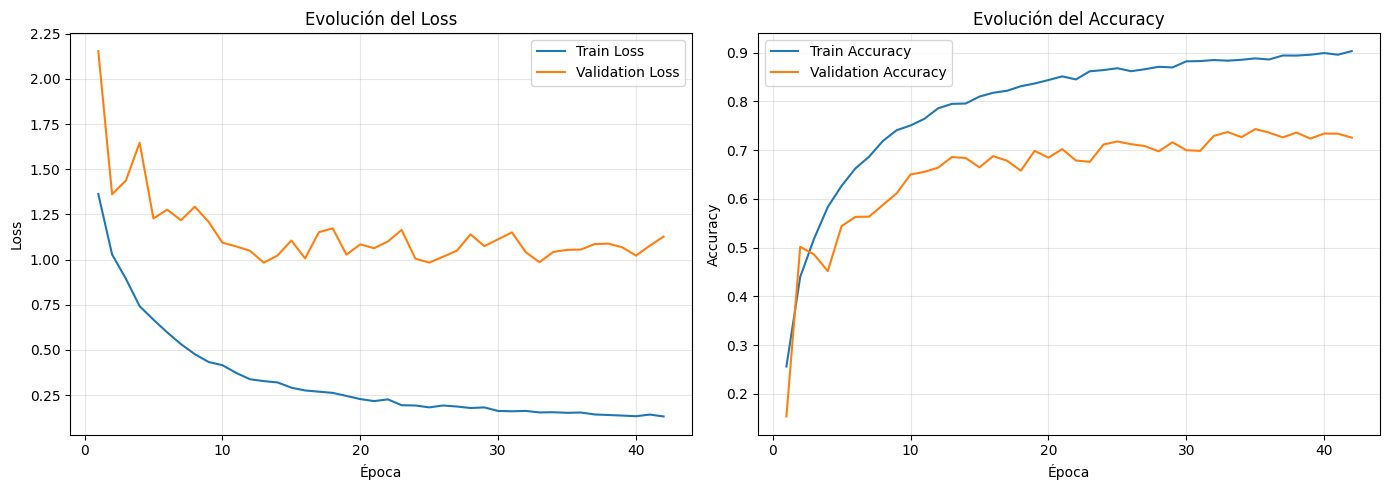

In [34]:
# === Curvas de entrenamiento: Loss y Accuracy ===
# - Usa los historiales generados durante el entrenamiento:
#   train_losses, eval_losses, train_accuracies, eval_accuracies

import matplotlib.pyplot as plt

# Eje de épocas para cada par de curvas (trunca al mínimo largo disponible)
epochs_loss = range(1, min(len(train_losses), len(eval_losses)) + 1)
epochs_acc  = range(1, min(len(train_accuracies), len(eval_accuracies)) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 fila, 2 columnas

# ----- Panel 1: Loss -----
axs[0].plot(epochs_loss, train_losses[:len(epochs_loss)], label="Train Loss")
axs[0].plot(epochs_loss, eval_losses[:len(epochs_loss)], label="Validation Loss")
axs[0].set_title("Evolución del Loss")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# ----- Panel 2: Accuracy -----
axs[1].plot(epochs_acc, train_accuracies[:len(epochs_acc)], label="Train Accuracy")
axs[1].plot(epochs_acc, eval_accuracies[:len(epochs_acc)], label="Validation Accuracy")
axs[1].set_title("Evolución del Accuracy")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# === Evaluación del modelo: accuracy, F1, reporte y matrices de confusión ===
# Requisitos:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns

def evaluate_model(model, loader, class_names):
    """
    Evalúa el modelo sobre un DataLoader y:
      - Imprime Accuracy y F1 (macro)
      - Imprime classification_report (precision/recall/F1 por clase)
      - Dibuja matriz de confusión absoluta y normalizada por fila

    Parámetros:
      model        : nn.Module entrenado
      loader       : DataLoader (val/test)
      class_names  : lista con los nombres de clase, en el orden de sus índices
    """
    model.eval()
    # Si no existe 'device' en el entorno, usamos el del modelo
    _device = (device if 'device' in globals()
               else (next(model.parameters()).device if any(p.requires_grad for p in model.parameters()) else 'cpu'))

    y_true, y_pred = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(_device)
            y = y.to(_device)

            logits = model(X)  # logits [B, C] en multiclase

            # Predicción por clase:
            if logits.ndim == 2:                   # multiclase
                preds_classes = logits.argmax(dim=1)
            else:                                   # binario: umbral 0.5
                preds_classes = (logits > 0.5).long()

            # Guardar como numpy en CPU
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds_classes.cpu().numpy())

    # A numpy para métricas
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Métricas globales
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')

    print(f"Accuracy en test: {acc:.4f}")
    print(f"F1 Score (macro) en test: {f1:.4f}\n")

    # Reporte por clase
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    # Matrices de confusión
    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Normalizada por fila (evitar división por cero)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums = np.clip(row_sums, 1, None)  # evita dividir por 0
    cm_norm = cm / row_sums

    # ----- Plots -----
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Matriz absoluta
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=axs[0]
    )
    axs[0].set_title("Matriz de Confusión (Absoluta)")
    axs[0].set_xlabel("Predicción")
    axs[0].set_ylabel("Real")

    # Matriz normalizada (proporciones por clase real)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Greens",
        xticklabels=class_names, yticklabels=class_names, ax=axs[1]
    )
    axs[1].set_title("Matriz de Confusión (Normalizada)")
    axs[1].set_xlabel("Predicción")
    axs[1].set_ylabel("Real")

    plt.tight_layout()
    plt.show()

Accuracy en test: 0.7256
F1 Score (macro) en test: 0.6500

Classification Report:
              precision    recall  f1-score   support

     alegria      0.967     0.767     0.856      1185
    disgusto      0.343     0.544     0.420       160
       enojo      0.660     0.660     0.660       162
       miedo      0.488     0.541     0.513        74
    seriedad      0.738     0.638     0.685       680
    sorpresa      0.672     0.818     0.738       329
    tristeza      0.592     0.795     0.679       478

    accuracy                          0.726      3068
   macro avg      0.637     0.680     0.650      3068
weighted avg      0.766     0.726     0.736      3068



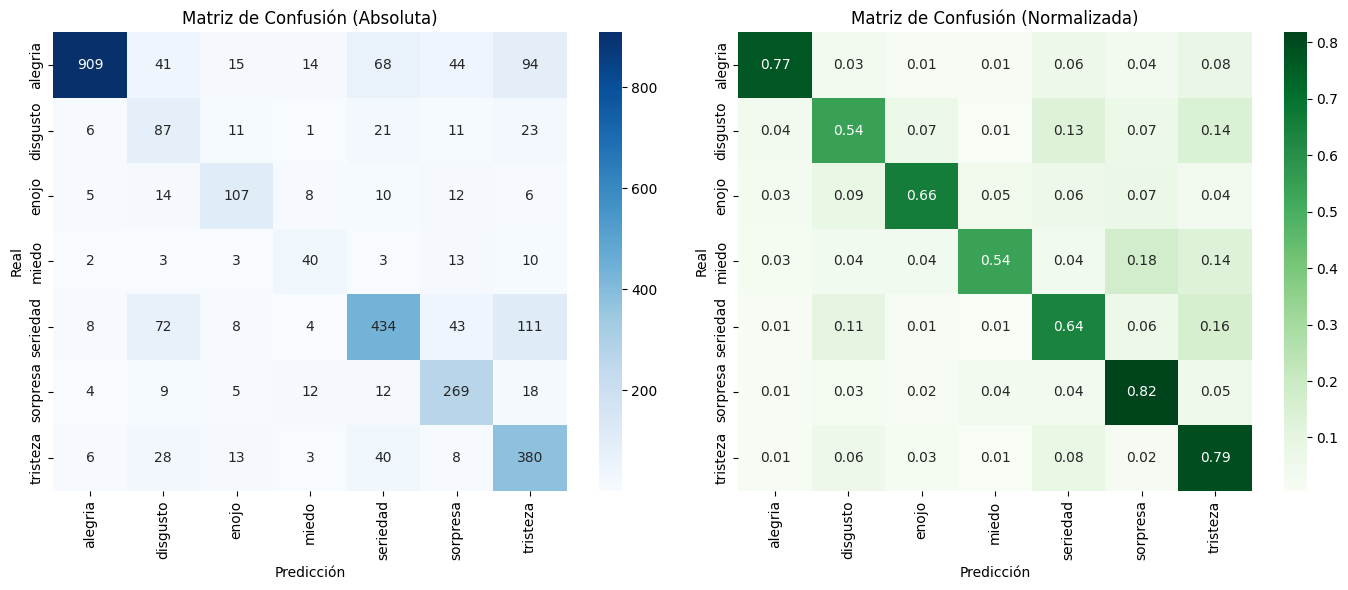

In [36]:
evaluate_model(model, dataloader['test'], class_names=train_ds.classes)

## Conclusiones de evaluación

**Resumen global.** El modelo alcanza **Accuracy en test = 0.7256** y **F1 macro = 0.6500**, superando el umbral objetivo (≥ 0.70). La diferencia entre **F1 macro (0.65)** y **weighted F1 (0.736)** refleja el **desbalance** (clases mayoritarias pesan más en el promedio ponderado).

### Lectura de las curvas
- **Loss:** la pérdida de entrenamiento desciende de forma sostenida; la de validación cae rápido al inicio y luego **oscila levemente** alrededor de ~1.0–1.2. No se observa sobreajuste severo; el *early stopping* corta cuando la mejora de *val* se estanca.
- **Accuracy:** el *train acc* crece hasta ~0.90, mientras que el *val acc* **se estabiliza** cerca de **0.72–0.74**. La **brecha** entre ambas curvas es moderada y consistente con un modelo con buena capacidad y regularización suficiente (Dropout + sampler/weights).

### Por clase (según el classification report)
- **Fuertes:**  
  - *alegría*: **precision 0.967**, **recall 0.767**, F1 0.856 (muchos aciertos y pocas predicciones falsas positivas; pierde parte de los positivos reales).  
  - *sorpresa*: **recall 0.818**, F1 0.738 (el modelo identifica bien esta emoción).  
  - *tristeza*: **recall 0.795**, F1 0.679 (buena cobertura; algo de confusión residual).
- **Intermedias:**  
  - *enojo*: recall 0.660, F1 0.660.  
  - *seriedad*: recall 0.638, F1 0.685 (tiende a confundirse con clases cercanas).
- **Más débiles (minoría):**  
  - *disgusto*: **recall 0.544**, F1 0.420.  
  - *miedo*: **recall 0.541**, F1 0.513.  
  Su **bajo soporte** (pocas muestras) y alta similitud visual con otras emociones pueden explicar parte del rendimiento.

### Qué muestra la matriz de confusión
- Diagonal **fuerte** en *alegría*, *sorpresa* y *tristeza*: confirma los buenos *recall*.  
- Confusiones frecuentes entre **clases próximas** semántica/visualmente:
  - *seriedad* ↔ *tristeza* (expresiones neutras vs. levemente negativas).
  - *miedo* ↔ *sorpresa*/*tristeza* (aperturas de boca/ojos vs. afecto negativo).
  - Parte de *disgusto* dispersa hacia *seriedad*/*tristeza*, coherente con su menor representación.
  
En conjunto, la matriz respalda que el modelo **captura bien** patrones salientes (alegría/sorpresa/tristeza) y le **cuesta** más en emociones ambiguas o **poco representadas** (disgusto/miedo), donde la variabilidad entre clases es mayor.

### Conclusión
El desempeño obtenido (**~72.6% de accuracy** y **0.65 F1 macro**) es **consistente** con el desafío del dataset y el desbalance entre clases. El modelo generaliza de manera razonable sin sobreajuste pronunciado, y las confusiones se concentran en pares de emociones naturalmente cercanas.


> En síntesis, el sistema cumple el objetivo y presenta un perfil de error razonable para la tarea: alto rendimiento en clases con rasgos más distintivos y margen de mejora en minoritarias/ambiguas.

 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 5 imágenes personales de cualquier relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación.

- Cada imagen debe representar una emoción distinta.

- Aplicar el mismo pre-procesamiento que se usó para el dataset durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 5 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase
  - La clase ganadora inferida por el modelo

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

NOTA: Pueden adaptar el código según crean conveniente para obtener mejores resultados.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6)

image_with_box = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis('off')

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis('off')
else:
    ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    ax[1].axis('off')

plt.tight_layout()
plt.show()
